In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys, os

from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent))

import pandas as pd
from general.dat_helper import group_by_mean
from glob import glob

print(os.getcwd())

from general.plot_settings import paper_settings, generate_plt_styles, colors
plt.rcParams.update(paper_settings)
colors = colors[0:]
# colors = ['blue', 'red']
styles = generate_plt_styles(colors=colors)
plt.rcParams['lines.markersize'] = 4
plt.rcParams['legend.fontsize'] = 7

c:\Users\colin\Documents\GitHub\chip-lab\ChiPyLab\examples


In [9]:
# Power (mW), PD voltage (V)
Rb = np.array([[249, 6.79], [160, 4.03], [0.005, 0.015]])
K = np.array([[305, 1.52], [48, 0.295], [0.005, 0.015]])

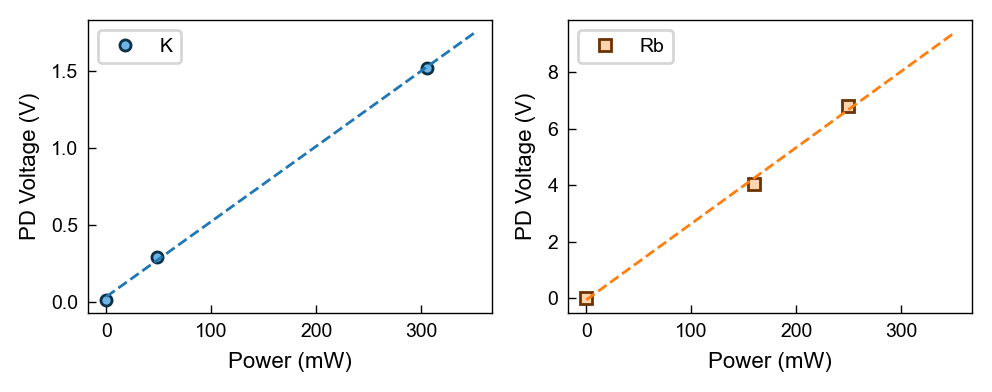

: 

In [ ]:
from scipy.optimize import curve_fit

y_name = 'PD Voltage (V)'
x_name = 'Power (mW)'

fig, axs = plt.subplots(1, 2, figsize=(5,2))


xmin = 0
xmax = 350
xs = np.linspace(xmin, xmax, 100)

# K
ax = axs[0]
i = 0
ax.set(xlabel=x_name, ylabel=y_name)

sty, color = (styles[i], colors[i])
ax.plot(K[:, 0], K[:, 1], **sty, label=r'K')

popt, pcov = curve_fit(lambda x, a, b: a * x + b, K[:, 0], K[:, 1])
K_fit = lambda x: popt[0] * x + popt[1]

ax.plot(xs, K_fit(xs), color=color, ls='--')

ax.legend()

# Rb
ax = axs[1]
i = 1
ax.set(xlabel=x_name, ylabel=y_name)

sty, color = (styles[i], colors[i])
ax.plot(Rb[:, 0], Rb[:, 1], **sty, label=r'Rb')

popt, pcov = curve_fit(lambda x, a, b: a * x + b, Rb[:, 0], Rb[:, 1])
Rb_fit = lambda x: popt[0] * x + popt[1]
ax.plot(xs, Rb_fit(xs), color=color, ls='--')

ax.legend()

fig.tight_layout()
# fig.savefig("outputs/LAT1_AM_spectroscopy.pdf")
plt.show()

In [3]:
mu_0 = 4 * np.pi * 1e-1  # G cm/A

def B_1(x, R, I):
    return mu_0 * I * R**2 / (2 * (R**2 + x**2)**(3/2))

total_B = 100 * (2*B_1(13.5/2, 14.2/2, 12))
print(f"Total B field: {total_B:.2f} G")


Total B field: 80.85 G


In [4]:
7/170


0.041176470588235294

In [18]:
def Vout(Vc, setpoint):
    R3 = 75e3
    if setpoint == 'HF':
        R1, R2 = 1.79e3, 590
    elif setpoint == 'LF':
        R1, R2 = 24e3, 609
    elif setpoint == 'MF':
        R1, R2 = 5e3, 1.2e3
    elif setpoint == 'HHF':
        R1, R2 = 350, 130

    Vin = 2.5
    return (Vin*R2*R3 + Vc*R1*R2)/(R1*R2 + R1*R3 + R2*R3)

print(f"The HHF midpoint is {Vout(0.0, 'HHF'):.3f} V")
print(f"The HF midpoint is {Vout(0.0, 'HF'):.3f} V")
print(f"The MF midpoint is {Vout(0.0, 'MF'):.3f} V")
print(f"The LF midpoint is {Vout(0.0, 'LF'):.3f} V")


print(f"The LF at 10V is {Vout(10.0, 'LF'):.3f} V")

The HHF midpoint is 0.676 V
The HF midpoint is 0.616 V
The MF midpoint is 0.478 V
The LF midpoint is 0.061 V
The LF at 10V is 0.140 V


The HHF midpoint is 0.676 V
The HF midpoint is 0.616 V
The MF midpoint is 1.990 V
The LF midpoint is 0.061 V
The LF at 10V is 0.140 V

1.0974025974025974